In [1]:
import numpy as np
import torchvision as thv

from torch import torch
from torch.utils.data import DataLoader
from torch.utils.data.sampler import SubsetRandomSampler, SequentialSampler

from utils import Utils
from consts import Consts
from feed_fwd_nn_model import FeedFwdNNModel

In [2]:
ds_train = thv.datasets.MNIST(
    root="./data"
    , train=True
    , download=True
    , transform=thv.transforms.Compose(
        [
            thv.transforms.ToTensor()
            , thv.transforms.Normalize(mean=Consts.DS_MEAN, std=Consts.DS_STD)
        ]
    )
)

idx_train = np.random.randint(
    low=0
    , high=ds_train.data.shape[0]
    , size=int(ds_train.data.shape[0] * Consts.DS_SAMPLING_RATIO)
)

loader_train = DataLoader(
    dataset=ds_train
    , batch_size=Consts.MINI_BATCH_SIZE
    , sampler=SubsetRandomSampler(idx_train)
)

print(idx_train.shape)
print(len(loader_train.sampler))

(60000,)
60000


In [3]:
ds_val = thv.datasets.MNIST(
    root="./data"
    , train=False
    , download=True
    , transform=thv.transforms.Compose(
        [
            thv.transforms.ToTensor()
            , thv.transforms.Normalize(mean=Consts.DS_MEAN, std=Consts.DS_STD)
        ]
    )
)

idx_val = np.arange(0, int(ds_val.data.shape[0] * Consts.DS_SAMPLING_RATIO))

loader_val = DataLoader(
    dataset=ds_val
    , batch_size=Consts.MINI_BATCH_SIZE
    , sampler=SequentialSampler(idx_val)
)

print(idx_val.shape)
print(len(loader_val.sampler))

(10000,)
10000


In [4]:
lrs = [0.1, 0.01]
dropout_ps = [0.1, 0.2, 0.5]
optimizer_algs = ["sgd", "adam"]
hidden_sizes = [[], [500], [1000], [1000, 500]]

models = {
    str(model): model for model in [
        FeedFwdNNModel(
            lr=lr
            , dropout_p=dropout_p
            , loader_val=loader_val
            , hidden_sizes=hidden_size
            , loader_train=loader_train
            , optimizer_alg=optimizer_alg
            , device_name=Utils.get_device_name()
        ) for lr in lrs for optimizer_alg in optimizer_algs for dropout_p in dropout_ps for hidden_size in hidden_sizes
    ]
}

idps = { model_name: model.train_and_validate() for model_name, model in models.items() }

model={sizes=[784, 10], device=cpu, epochs=50, lr=0.1, optim=sgd, dropout=0.1}


100%|██████████| 50/50 [04:29<00:00,  5.39s/it]


model={sizes=[784, 500, 10], device=cpu, epochs=50, lr=0.1, optim=sgd, dropout=0.1}


100%|██████████| 50/50 [05:20<00:00,  6.41s/it]


model={sizes=[784, 1000, 10], device=cpu, epochs=50, lr=0.1, optim=sgd, dropout=0.1}


...

100%|██████████| 50/50 [05:32<00:00,  6.65s/it]


model={sizes=[784, 1000, 10], device=cpu, epochs=50, lr=0.01, optim=adam, dropout=0.5}


100%|██████████| 50/50 [06:41<00:00,  8.02s/it]


model={sizes=[784, 1000, 500, 10], device=cpu, epochs=50, lr=0.01, optim=adam, dropout=0.5}


100%|██████████| 50/50 [08:00<00:00,  9.62s/it]


In [ ]:
top_model_names = [
    kvp[0] for kvp in sorted(
        list(idps.items())
        , key=lambda kvp: min(
            kvp[1]
            , key=lambda idp: idp.validation_error
        ).validation_error
    )[:Consts.K_TOP_MODELS]
]

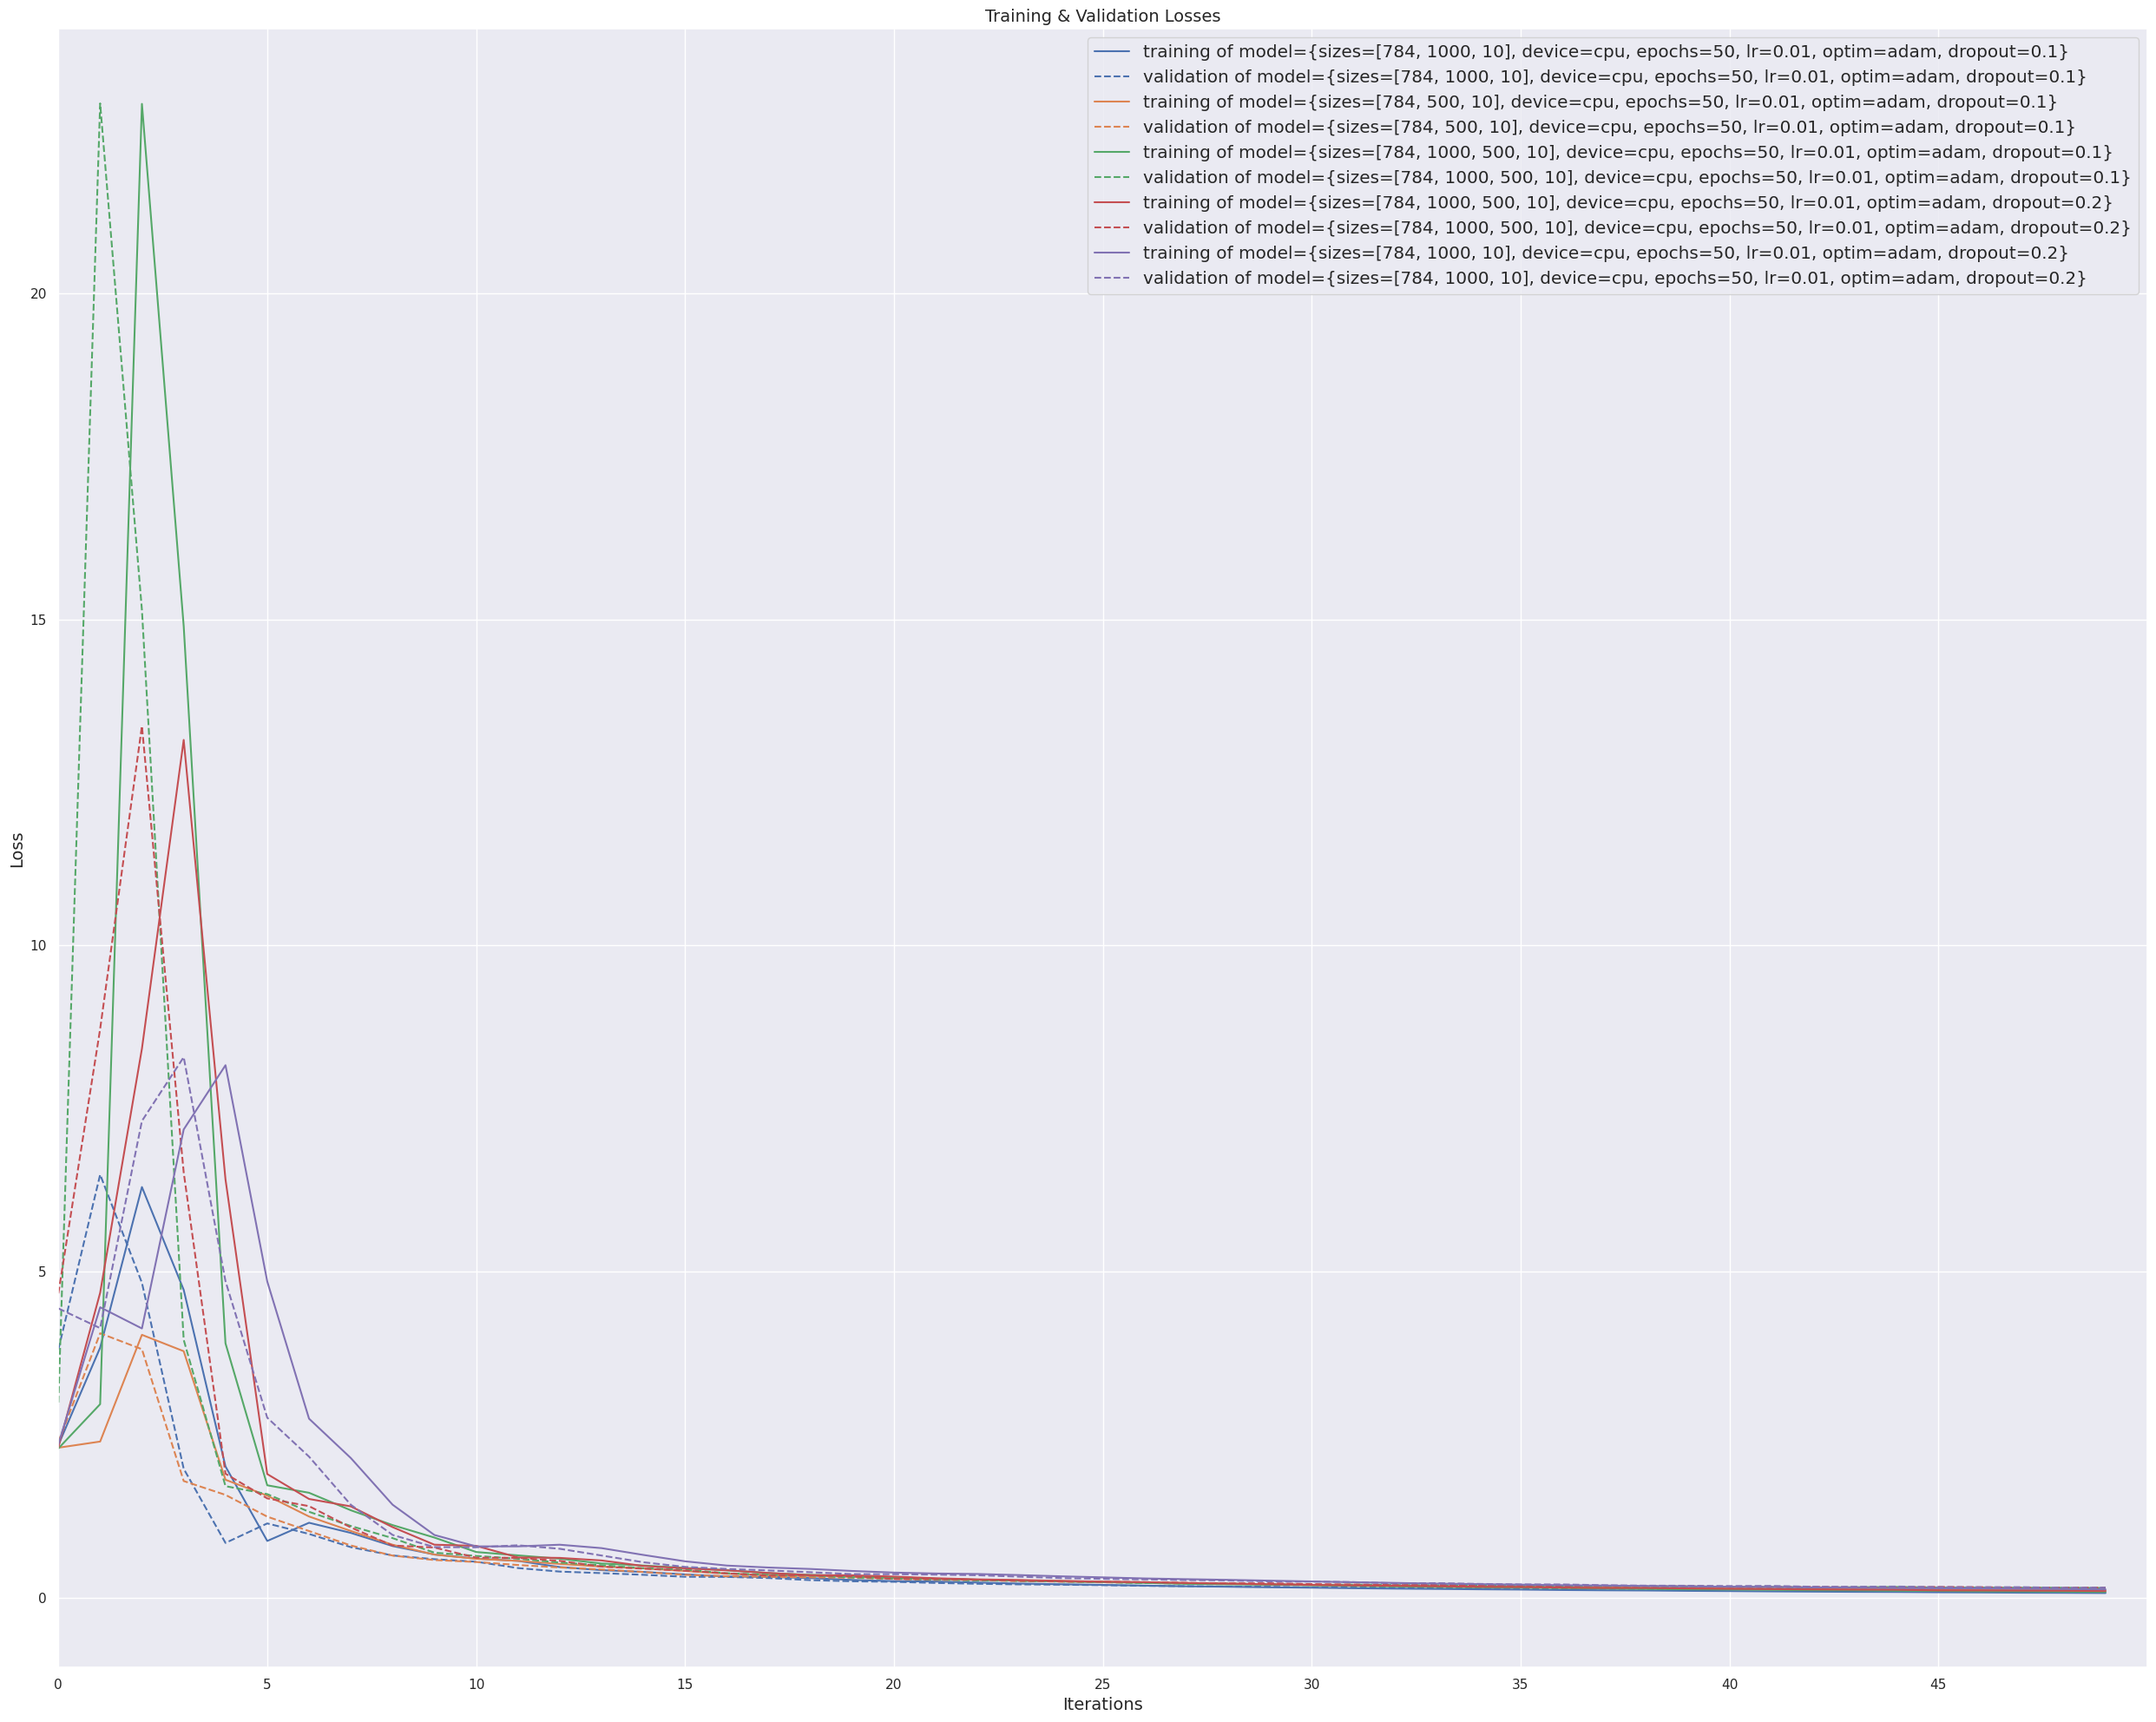

In [21]:
Utils.multi_line_plot(
    x_ticks_inc=5
    , fig_size=(25, 20)
    , y_axis_label="Loss"
    , x_axis_label="Iterations"
    , title=f"Training & Validation Losses"
    , x=[idp.iter_idx for idp in idps[top_model_names[0]]]
    , yss_legend=[[f"{loss_type} of {model_name}" for loss_type in ["training", "validation"]] for model_name in top_model_names]
    , yss=[[[model_idp.training_loss for model_idp in idps[model_name]], [model_idp.validation_loss for model_idp in idps[model_name]]] for model_name in top_model_names]
)

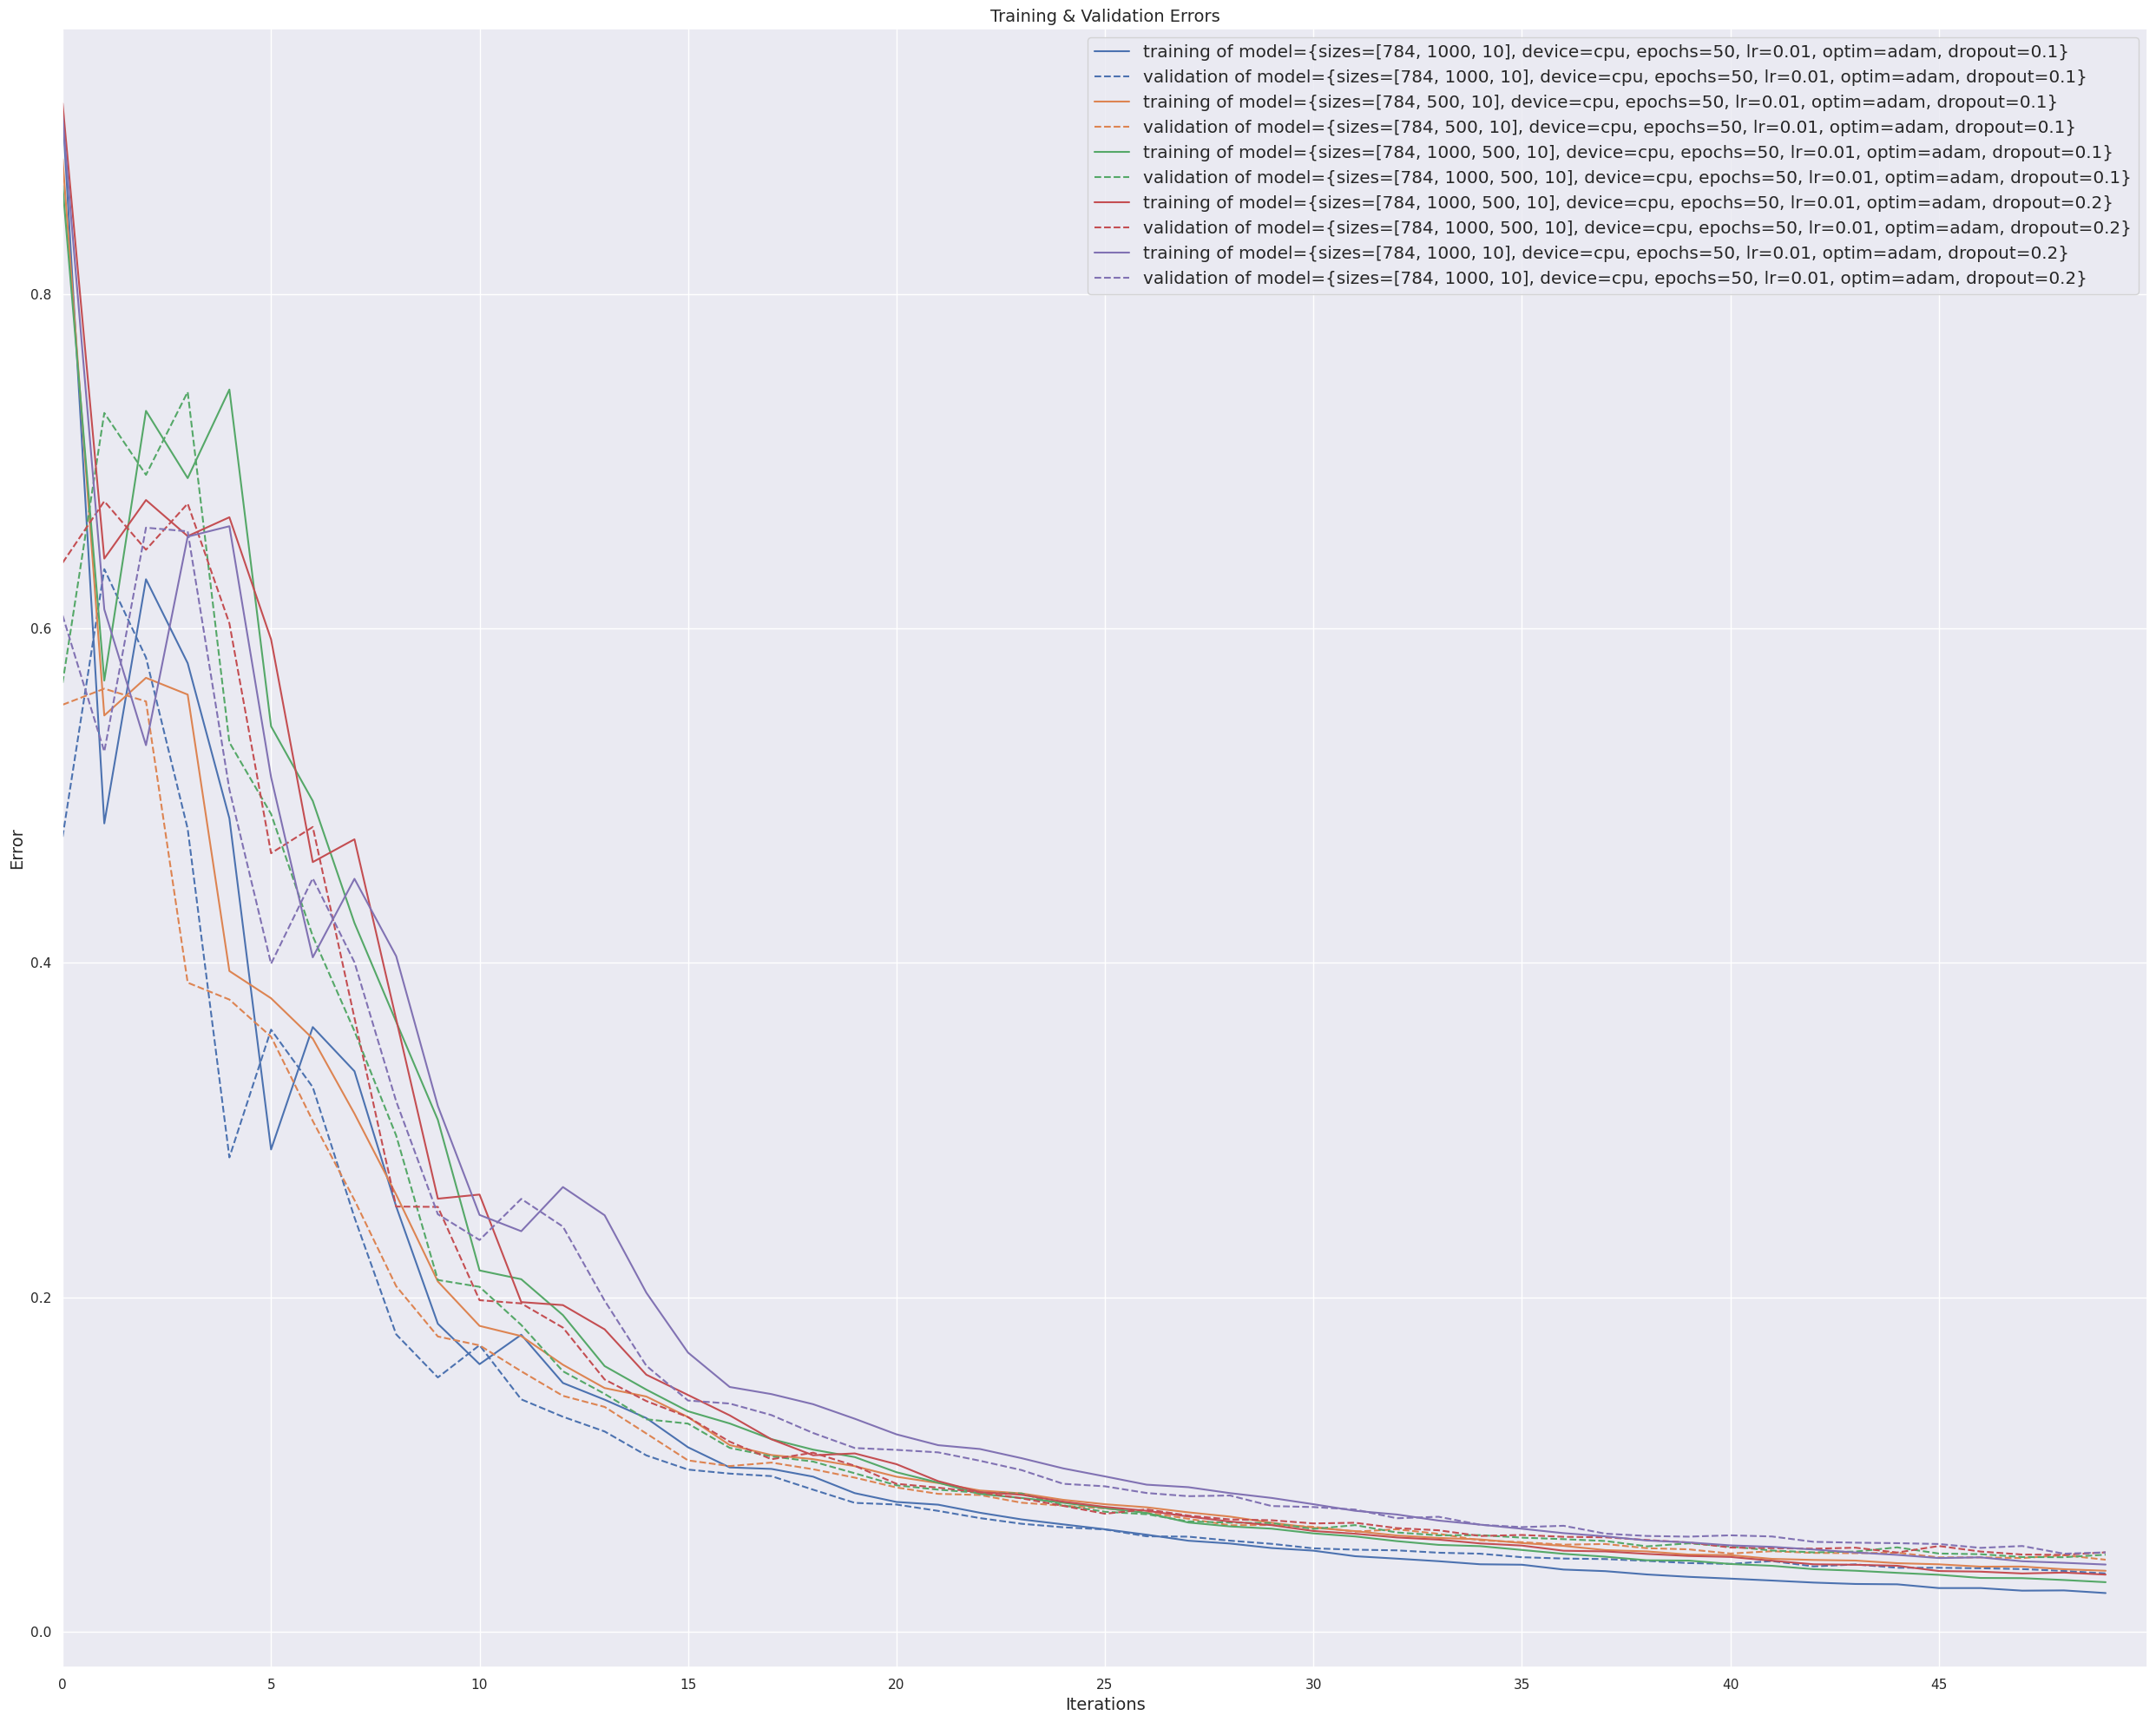

In [20]:
Utils.multi_line_plot(
    x_ticks_inc=5
    , fig_size=(25, 20)
    , y_axis_label="Error"
    , x_axis_label="Iterations"
    , title=f"Training & Validation Errors"
    , x=[idp.iter_idx for idp in idps[top_model_names[0]]]
    , yss_legend=[[f"{error_type} of {model_name}" for error_type in ["training", "validation"]] for model_name in top_model_names]
    , yss=[[[model_idp.training_error for model_idp in idps[model_name]], [model_idp.validation_error for model_idp in idps[model_name]]] for model_name in top_model_names]
)

In [24]:
print(f"best is {top_model_names[0]} and achieves validation error of {min(idps[top_model_names[0]], key=lambda idp: idp.validation_error).validation_error}")

best is model={sizes=[784, 1000, 10], device=cpu, epochs=50, lr=0.01, optim=adam, dropout=0.1} and achieves validation error of 0.03480000048875809
